# Disaster Tweets — text CNN trained from scratch

Kim (2014), *Convolutional Neural Networks for Sentence Classification*, in its **randomly initialised** form (CNN-rand): no
pre-trained word vectors. A tweet of $n\le40$ words becomes a matrix $\mathbf X\in\mathbb R^{n\times d}$ of learned embeddings;
filters of widths $h\in\{2,3,4\}$ slide over $h$ consecutive words,

$$c^{(f)}_i=\mathrm{ReLU}\big(\mathbf w_f\cdot\mathbf x_{i:i+h-1}+b_f\big),\qquad \hat c_f=\max_i c^{(f)}_i,$$

the max-over-time pooled features of all filters are concatenated, dropped out (p = 0.5) and fed to a linear layer. A filter is
therefore a learned *n-gram detector*: it fires on a particular 2–4-word pattern wherever it occurs.

The character-level CNN of Zhang et al. (2015) was considered and rejected: it was designed for datasets of hundreds of
thousands to millions of documents and would overfit 6k tweets.

**Protocol** (identical to the fastText notebook). Same five folds; 10% of each fold's training rows is an inner set that selects the
best epoch; the outer validation fold is watched only. Two seeds per fold are averaged. Statistics are collected during training; figures are drawn afterwards.

In [1]:
import time, json, os
import numpy as np, pandas as pd, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, seaborn as sns
from matplotlib.patches import Rectangle
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score
import nlp_common as N, nlp_dl as D
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
PAL = ["#4C72B0", "#C44E52", "#55A868", "#8172B2"]
dev = "cuda" if torch.cuda.is_available() else "cpu"; print("device:", dev, torch.cuda.get_device_name(0) if dev == "cuda" else "")
train, test, folds = N.load(); y = train.target.values; X, TX = N.model_text(train), N.model_text(test)
import train_dl as TD
SPEC = TD.SPECS["textcnn"]; CFG, DIM, CH, SEEDS = SPEC["cfg"], SPEC["dim"], SPEC["channels"], SPEC["seeds"]; print("config:", CFG, "embedding", DIM, "channels", CH, "seeds", SEEDS)

device: cuda NVIDIA GeForce GTX 1650 Ti


config: {'lr': 0.002, 'wd': 0.01, 'batch': 256, 'epochs': 30, 'patience': 6, 'lr_patience': 2} embedding 64 channels 64 seeds [0, 1]


## Training (statistics only)

Training is done by `train_dl.py textcnn`: resumable, one saved record per (fold, seed) run (per-epoch statistics, predictions, weights),
and it stops starting new runs once its time budget is used, so a single invocation stays short. This notebook assembles the
saved runs; nothing is retrained here.

In [2]:
res = TD.assemble("textcnn"); assert res is not None, "training incomplete: run `python3 train_dl.py textcnn` again"
oof_s, test_s, runs = res; oof_logit, test_logit = oof_s.mean(0), test_s.mean(0); ev = N.evaluate(y, oof_logit, folds)
tot = sum(h["seconds"] for r in runs for h in r["history"]); print(f"Text CNN: AUC {ev['auc']:.4f}  F1 {ev['f1']:.4f} {np.round(ev['f1_ci95'], 4)}  ({len(runs)} runs, {tot:.0f}s of training on the GPU)")
single = [N.evaluate(y, oof_s[i], folds, n_boot=20) for i in range(len(SEEDS))]; print("single-seed F1:", [round(e["f1"], 4) for e in single], "AUC:", [round(e["auc"], 4) for e in single])
N.save_method("textcnn", oof_logit, test_logit, dict(kind="logit", dim=DIM, channels=CH, widths=[2, 3, 4], seeds=SEEDS, cfg=CFG, **ev))
d0 = TD.prepare_fold("textcnn", 0, train, test, folds, dev); m0 = TD.load_model("textcnn", d0)
models = dict(m=m0, V=d0["V"], Xa=d0["Xa"], tr_texts=d0["texts"], Xv=d0["Xv"], va=d0["va"])

Text CNN: AUC 0.8440  F1 0.7397 [0.7277 0.7513]  (10 runs, 30s of training on the GPU)


single-seed F1: [0.7287, 0.7202] AUC: [0.8325, 0.8328]


## In-training statistics

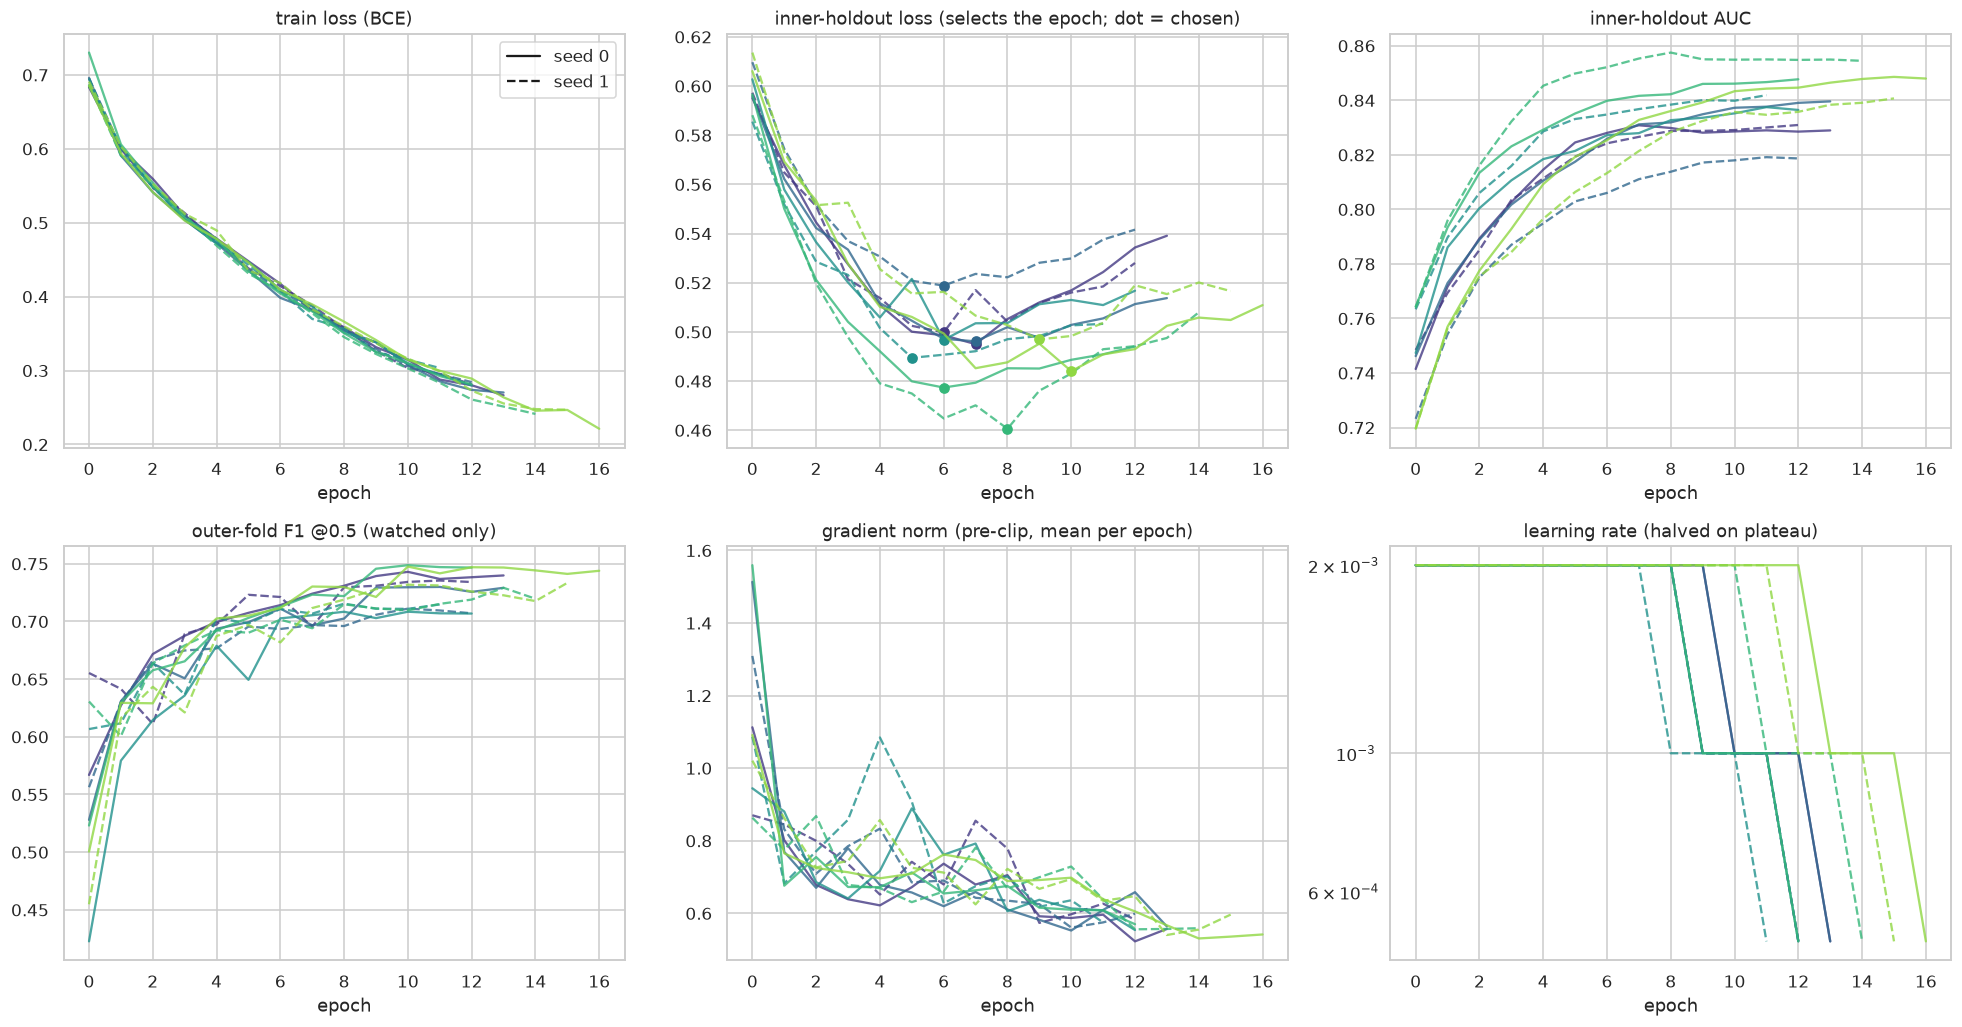

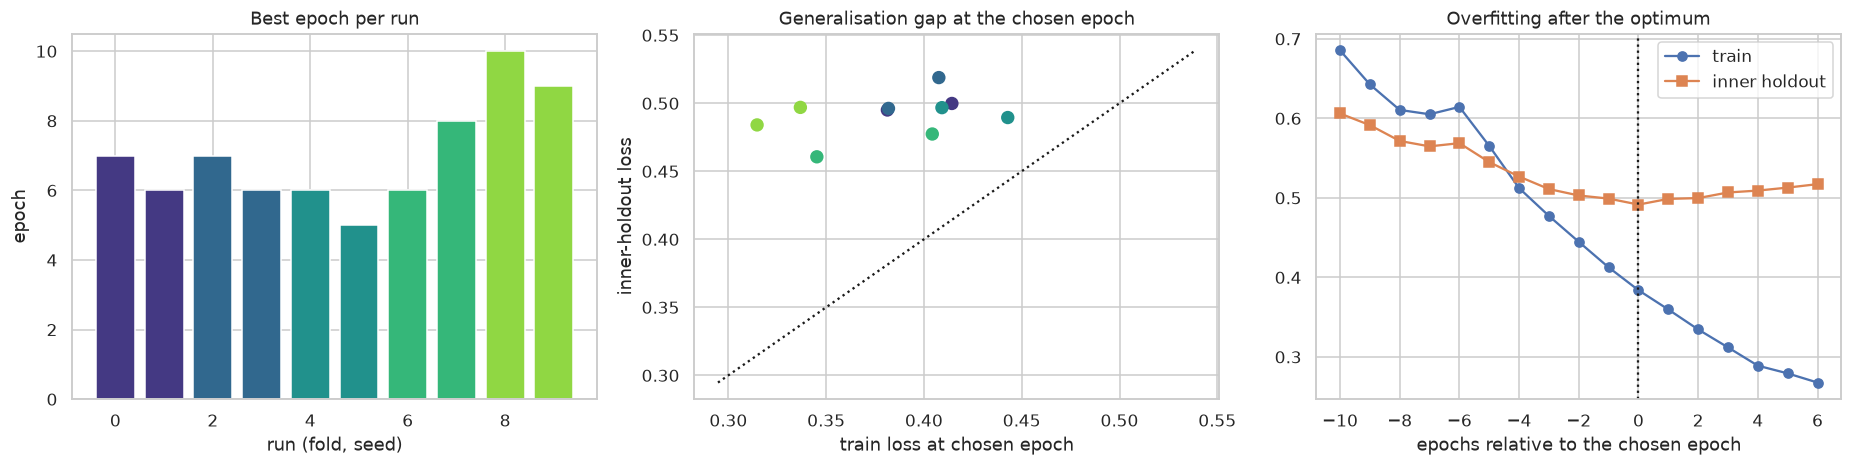

,fold,seed,best_epoch,epochs,seconds,train_loss,inner_loss
0,0,0,7,14,7.5765,0.3813,0.4950
1,0,1,6,13,1.9743,0.4143,0.4998
2,1,0,7,14,3.0712,0.3819,0.4962
3,1,1,6,13,3.0785,0.4076,0.5188
4,2,0,6,13,2.0791,0.4092,0.4967
5,2,1,5,12,1.8231,0.4429,0.4895
6,3,0,6,13,2.0150,0.4043,0.4774
7,3,1,8,15,2.7098,0.3452,0.4606
8,4,0,10,17,2.9437,0.3147,0.4840
9,4,1,9,16,2.3180,0.3368,0.4969


In [3]:
H = pd.concat([pd.DataFrame(r["history"]).assign(fold=r["fold"], seed=r["seed"], best=r["best_epoch"]) for r in runs])
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5)); cs = sns.color_palette("viridis", 5)
for (k, s), g in H.groupby(["fold", "seed"]):
    ls = "-" if s == 0 else "--"; c = cs[k]
    axes[0, 0].plot(g.epoch, g.train_loss, ls, color=c, alpha=.8); axes[0, 1].plot(g.epoch, g.inner_loss, ls, color=c, alpha=.8)
    axes[0, 2].plot(g.epoch, g.inner_auc, ls, color=c, alpha=.8); axes[1, 0].plot(g.epoch, g.mon_f1, ls, color=c, alpha=.8)
    axes[1, 1].plot(g.epoch, g.grad_norm, ls, color=c, alpha=.8); axes[1, 2].plot(g.epoch, g.lr, ls, color=c, alpha=.8)
    axes[0, 1].plot(g.best.iloc[0], g.inner_loss.min(), "o", color=c, ms=6)
axes[1, 2].set_yscale("log")
for ax, t in zip(axes.ravel(), ["train loss (BCE)", "inner-holdout loss (selects the epoch; dot = chosen)", "inner-holdout AUC", "outer-fold F1 @0.5 (watched only)", "gradient norm (pre-clip, mean per epoch)", "learning rate (halved on plateau)"]):
    ax.set_title(t); ax.set_xlabel("epoch")
axes[0, 0].plot([], [], "k-", label="seed 0"); axes[0, 0].plot([], [], "k--", label="seed 1"); axes[0, 0].legend()
plt.tight_layout(); plt.savefig("assets/textcnn_01_training_statistics.png", bbox_inches="tight"); plt.show()
R = pd.DataFrame([dict(fold=r["fold"], seed=r["seed"], best_epoch=r["best_epoch"], epochs=r["n_epochs"], seconds=sum(h["seconds"] for h in r["history"]),
        train_loss=r["history"][r["best_epoch"]]["train_loss"], inner_loss=r["history"][r["best_epoch"]]["inner_loss"]) for r in runs])
fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
axes[0].bar(range(len(R)), R.best_epoch, color=[cs[f] for f in R.fold]); axes[0].set_xlabel("run (fold, seed)"); axes[0].set_ylabel("epoch"); axes[0].set_title("Best epoch per run")
axes[1].scatter(R.train_loss, R.inner_loss, c=[cs[f] for f in R.fold], s=60); lim = [R.train_loss.min() - .02, R.inner_loss.max() + .02]; axes[1].plot(lim, lim, "k:"); axes[1].set_xlabel("train loss at chosen epoch"); axes[1].set_ylabel("inner-holdout loss"); axes[1].set_title("Generalisation gap at the chosen epoch")
last = H[H.epoch <= H.best + 6]; piv = last.assign(rel=last.epoch - last.best).groupby("rel")[["train_loss", "inner_loss"]].mean()
axes[2].plot(piv.index, piv.train_loss, "o-", label="train"); axes[2].plot(piv.index, piv.inner_loss, "s-", label="inner holdout"); axes[2].axvline(0, color="k", ls=":"); axes[2].legend(); axes[2].set_xlabel("epochs relative to the chosen epoch"); axes[2].set_title("Overfitting after the optimum")
plt.tight_layout(); plt.savefig("assets/textcnn_02_generalisation.png", bbox_inches="tight"); plt.show(); display(R.round(4))

## Post-training analysis

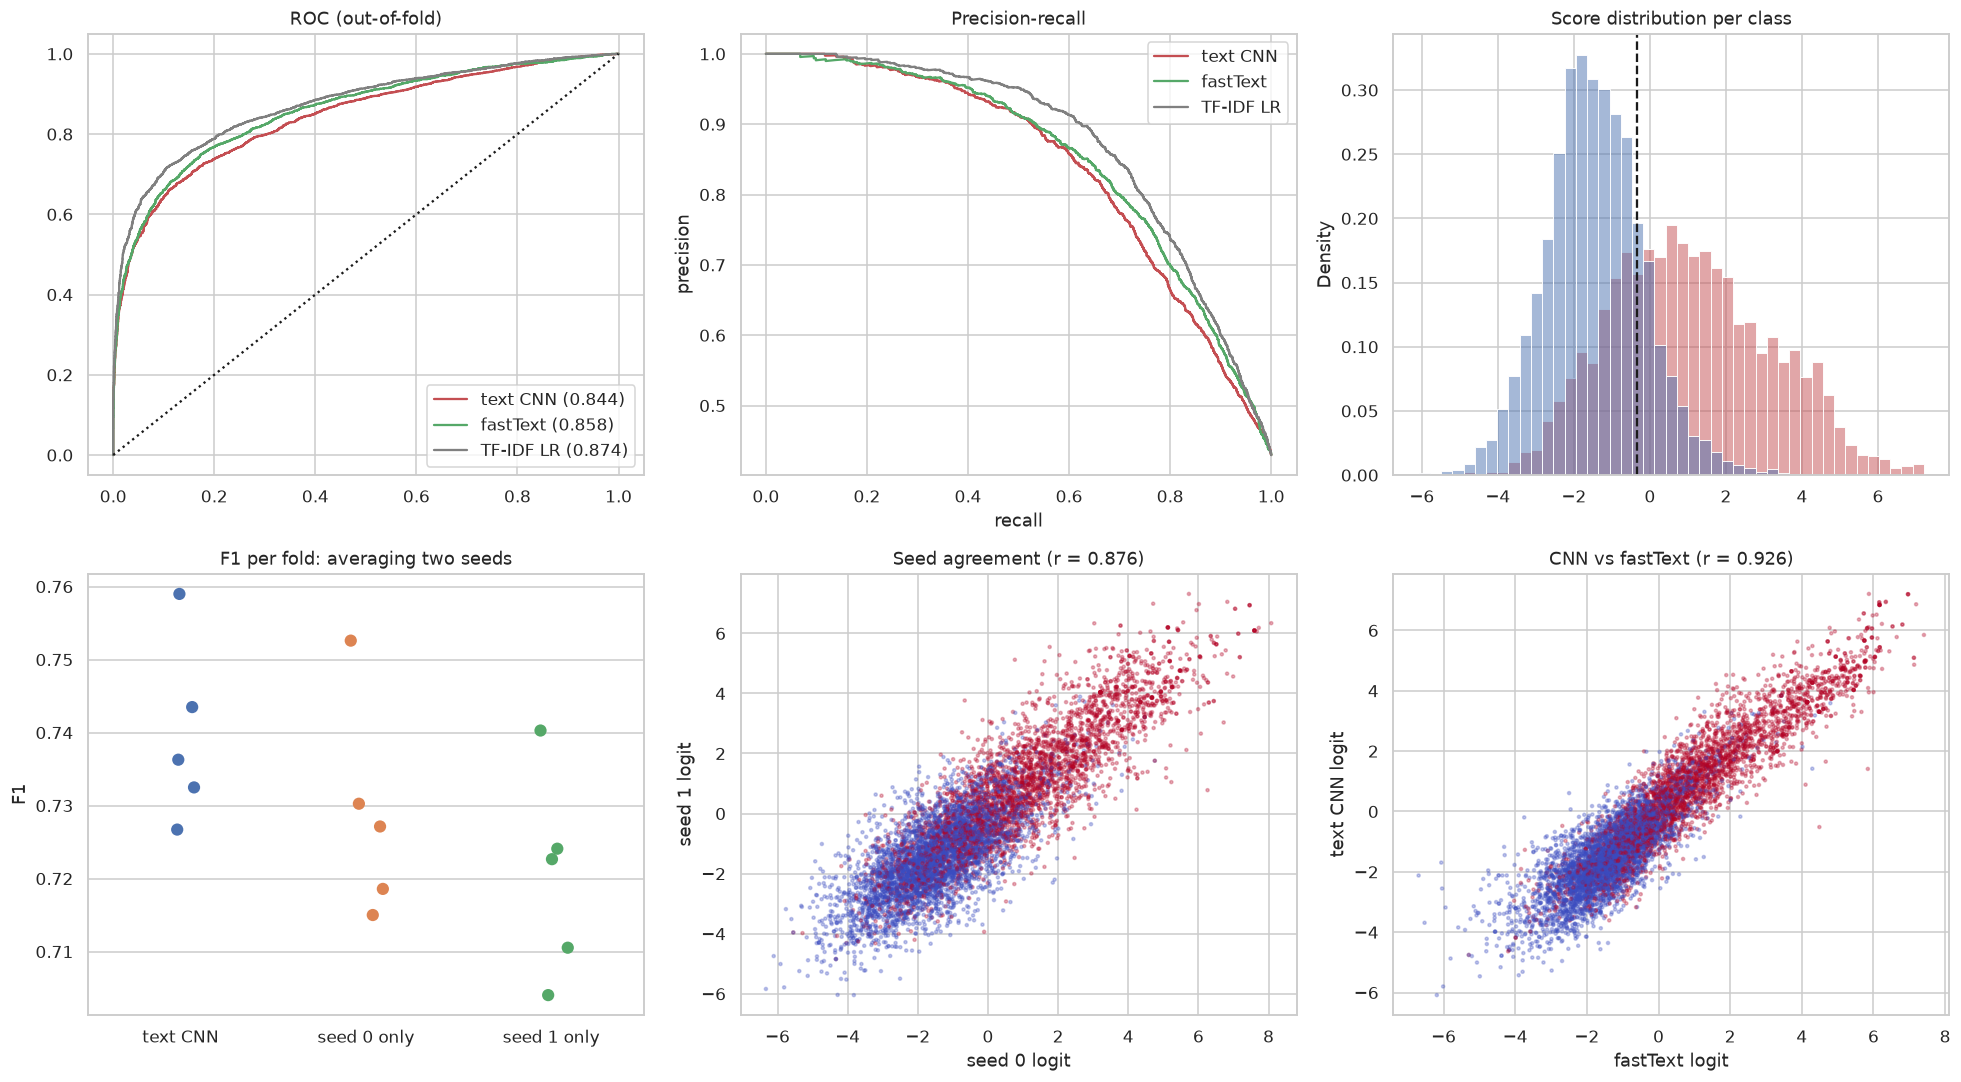

In [4]:
base = np.load("results/v1_tfidf_oof.npy"); ft = N.load_method("fasttext")[0]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for nm, o, c in [("text CNN", oof_logit, PAL[1]), ("fastText", ft, PAL[2]), ("TF-IDF LR", base, "grey")]:
    f, t, _ = roc_curve(y, o); axes[0, 0].plot(f, t, color=c, label=f"{nm} ({roc_auc_score(y, o):.3f})"); pr, rc, _ = precision_recall_curve(y, o); axes[0, 1].plot(rc, pr, color=c, label=nm)
axes[0, 0].plot([0, 1], [0, 1], "k:"); axes[0, 0].legend(); axes[0, 0].set_title("ROC (out-of-fold)"); axes[0, 1].legend(); axes[0, 1].set_title("Precision-recall"); axes[0, 1].set_xlabel("recall"); axes[0, 1].set_ylabel("precision")
sns.histplot(x=oof_logit, hue=y, bins=45, stat="density", common_norm=False, palette=["#4C72B0", "#C44E52"], ax=axes[0, 2], legend=False); axes[0, 2].axvline(ev["threshold"], color="k", ls="--"); axes[0, 2].set_title("Score distribution per class")
ff = pd.DataFrame({"text CNN": ev["fold_f1"], "seed 0 only": single[0]["fold_f1"], "seed 1 only": single[1]["fold_f1"]}); sns.stripplot(data=ff, ax=axes[1, 0], size=8); axes[1, 0].set_title("F1 per fold: averaging two seeds"); axes[1, 0].set_ylabel("F1")
axes[1, 1].scatter(oof_s[0], oof_s[1], s=4, alpha=.3, c=y, cmap="coolwarm"); axes[1, 1].set_xlabel("seed 0 logit"); axes[1, 1].set_ylabel("seed 1 logit"); axes[1, 1].set_title(f"Seed agreement (r = {np.corrcoef(oof_s[0], oof_s[1])[0,1]:.3f})")
axes[1, 2].scatter(ft, oof_logit, s=4, alpha=.3, c=y, cmap="coolwarm"); axes[1, 2].set_xlabel("fastText logit"); axes[1, 2].set_ylabel("text CNN logit"); axes[1, 2].set_title(f"CNN vs fastText (r = {np.corrcoef(ft, oof_logit)[0,1]:.3f})")
plt.tight_layout(); plt.savefig("assets/textcnn_03_post_training.png", bbox_inches="tight"); plt.show()

### What the filters detect

For each width-3 filter, the three word windows (over the training tweets of fold 0) on which it fires most strongly; filters are
ranked by the size of their weight in the output layer.

,filter,weight,fires_on
0,8,-0.095,i see fit | your friends really | this summer h | i ve ever
1,23,0.094,cliff but you're | jupiter's great red | vintage leather briefcase | them hope you're
2,38,0.080,tote cross body | bag cross body | handbags cross body | wants russian body
3,16,0.079,fires near where | suicide bombing against | severe weather bulletin | soldiers killed in
4,2,-0.078,today your life | in this life | not a catastrophe | in a matter
5,15,0.076,scale action figure | fantasy football pool | my love for | my boy wreck
6,37,0.075,grenades were not | heading north on | that would not | bombing were purely
7,19,0.075,fires areas affected | green line at | kw_flooding business at | spring oil spill
8,35,-0.073,5 1620 one | destruction restricted to | you anything but | international conference centre
9,56,0.073,straight body bagging | is body bagging | xuser body bagging | cross body canvas


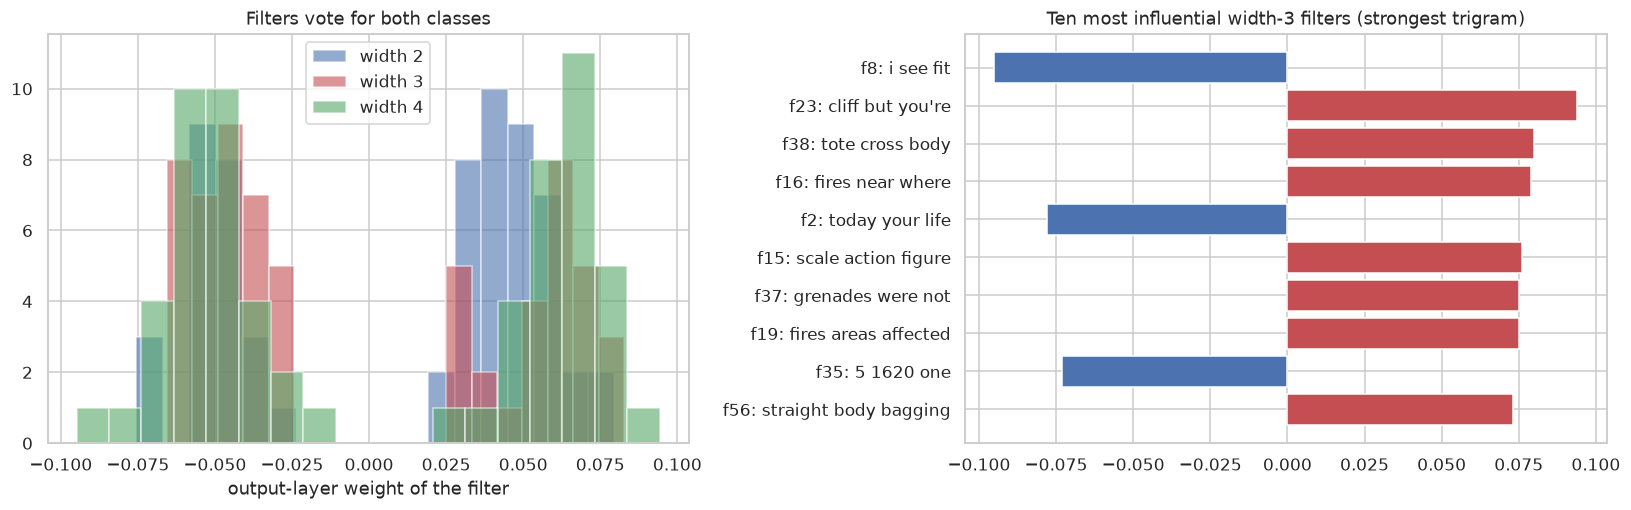

In [5]:
m, V, Xa, texts = models["m"].eval(), models["V"], models["Xa"], models["tr_texts"]
with torch.no_grad():
    e = m.emb(Xa).transpose(1, 2); conv3 = m.convs[1]; act = F.relu(conv3(e)).cpu().numpy()   # (N, C, L-2)
W = m.out.weight.detach().cpu().numpy().ravel(); base_off = 2 * CH
rows = []
for f in np.argsort(-np.abs(W[base_off:base_off + CH]))[:10]:
    flat = act[:, f, :]; top = np.dstack(np.unravel_index(np.argsort(-flat.ravel())[:60], flat.shape))[0]; seen = []
    for n, p in top:
        ws = texts[n].split()[p:p + 3]
        if len(ws) == 3 and " ".join(ws) not in seen: seen.append(" ".join(ws))
        if len(seen) == 4: break
    rows.append(dict(filter=int(f), weight=round(float(W[base_off + f]), 3), fires_on=" | ".join(seen)))
F3 = pd.DataFrame(rows); pd.set_option("display.max_colwidth", 120); display(F3)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for h_, (c, col) in enumerate(zip(m.convs, PAL)): axes[0].hist(W[h_ * CH:(h_ + 1) * CH], bins=18, alpha=.6, color=col, label=f"width {h_ + 2}")
axes[0].set_xlabel("output-layer weight of the filter"); axes[0].set_title("Filters vote for both classes"); axes[0].legend()
axes[1].barh([f"f{r['filter']}: " + r["fires_on"].split(" | ")[0][:34] for r in rows][::-1], [r["weight"] for r in rows][::-1], color=[PAL[1] if r["weight"] > 0 else PAL[0] for r in rows][::-1]); axes[1].set_title("Ten most influential width-3 filters (strongest trigram)")
plt.tight_layout(); plt.savefig("assets/textcnn_04_filters.png", bbox_inches="tight"); plt.show()

### Token saliency on held-out tweets

Gradient × embedding, summed over embedding dimensions: red tokens raised the disaster logit, blue tokens lowered it. Examples:
the most confident correct disaster tweet, the most confident correct non-disaster tweet, and the most confident error of each kind.

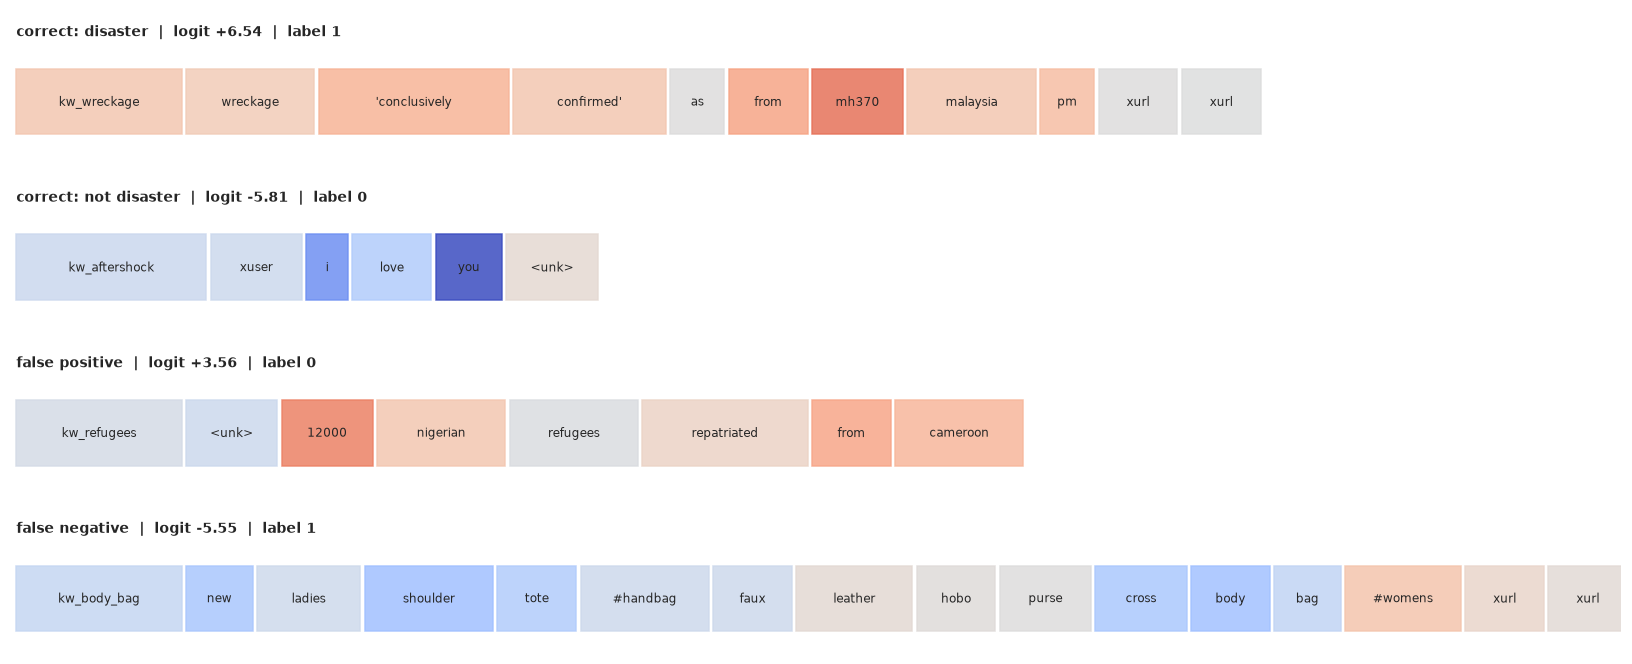

In [6]:
Xv, va = models["Xv"], models["va"]; m.eval(); zv = D.predict_logits(m, Xv); yv = y[va]
pick = [("correct: disaster", np.where(yv == 1)[0][np.argmax(zv[yv == 1])]), ("correct: not disaster", np.where(yv == 0)[0][np.argmin(zv[yv == 0])]),
        ("false positive", np.where(yv == 0)[0][np.argmax(zv[yv == 0])]), ("false negative", np.where(yv == 1)[0][np.argmin(zv[yv == 1])])]
def saliency(i):
    x = Xv[i:i + 1]; emb = m.emb(x).detach().requires_grad_(True); logit = m.forward_emb(emb); logit.backward()
    s = (emb.grad * emb.detach()).sum(-1)[0].cpu().numpy(); n = int((x[0] != 0).sum()); return [V.itos[t] for t in x[0, :n].tolist()], s[:n], float(logit.detach())
fig, axes = plt.subplots(4, 1, figsize=(15, 6.2)); lim = 0
sal = [saliency(i) for _, i in pick]; lim = max(np.abs(s).max() for _, s, _ in sal)
for ax, (name, i), (ws, s, z) in zip(axes, pick, sal):
    ax.set_xlim(0, 30); ax.set_ylim(0, 1); ax.axis("off"); x0 = 0.1
    ax.text(x0, 0.9, f"{name}  |  logit {z:+.2f}  |  label {int(yv[i])}", fontsize=9, weight="bold", va="top")
    for w, v in zip(ws, s):
        wd = 0.55 + 0.23 * len(w); col = plt.cm.coolwarm(0.5 + 0.5 * v / lim)
        ax.add_patch(Rectangle((x0, 0.15), wd, 0.45, color=col, alpha=.85)); ax.text(x0 + wd / 2, 0.37, w, ha="center", va="center", fontsize=8); x0 += wd + 0.08
plt.tight_layout(); plt.savefig("assets/textcnn_05_token_saliency.png", bbox_inches="tight"); plt.show()